In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer


import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Indian Cities AQI.csv')
df.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


## $$Data Screening$$

Getting a better understanding of the data

---

In [4]:
print(df.isna().sum())

df.info()

date                                  0
state                                 0
area                                  0
number_of_monitoring_stations         0
prominent_pollutants                  0
aqi_value                             0
air_quality_status                    0
unit                                  0
note                             235785
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  object 
 1   state                          235785 non-null  object 
 2   area                           235785 non-null  object 
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  object 
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status      

In [5]:
df.describe()

,number_of_monitoring_stations,aqi_value,note
count,235785.000000,235785.000000,0.0
mean,1.870653,111.127294,NaN
std,3.071575,71.447353,NaN
min,1.000000,3.000000,NaN
25%,1.000000,59.000000,NaN
50%,1.000000,92.000000,NaN
75%,1.000000,142.000000,NaN
max,40.000000,500.000000,NaN


In [6]:
df.nunique()

date                             1125
state                              32
area                              291
number_of_monitoring_stations      40
prominent_pollutants               49
aqi_value                         472
air_quality_status                  6
unit                                1
note                                0
dtype: int64

In [7]:
df['prominent_pollutants'].unique()

array(['PM10', 'CO', 'O3', 'PM2.5', 'SO2', 'PM2.5,PM10', 'PM10,NO2',
       'PM10,O3', 'O3,PM2.5,PM10', 'PM10,O3,CO', 'PM10,CO', 'PM2.5,O3',
       'PM10,SO2', 'PM2.5,CO,O3', 'NO2', 'PM10,PM2.5,NO2', 'CO,O3',
       'PM2.5,PM10,CO', 'PM2.5,SO2,O3', 'PM10,NO2,O3', 'SO2,O3',
       'PM10,NH3,CO', 'PM10,NO2,PM2.5,O3', 'NO2,PM10,CO', 'CO,SO2',
       'PM2.5,NO2', 'PM10,CO,SO2', 'PM2.5,NO2,SO2', 'PM10,SO2,O3',
       'PM10,NO2,SO3', 'PM2.5,NH3,O3', 'PM10,PM2.5,SO2', 'NO2,O3',
       'PM2.5,SO2', 'CO,NO2', 'NH3', 'PM2.5,CO,NO2', 'PM2.5,NH3',
       'NO2,SO2', 'PM2.5,CO,SO2', 'SO3,CO,O3', 'NO2,CO,O3', 'NO2,SO2,CO',
       'NO2,O3,SO2', 'PM10,NH3', 'NH3,CO,O3', 'PM10,NH3,O3', 'O3,NH3',
       'PM2.5,NH3,CO'], dtype=object)

In [8]:
# # removing the useless feature

df.drop(columns=['note', 'unit'], inplace=True)

In [9]:
# splitting the pollutant column

col_split = df['prominent_pollutants'].str.split(',', expand=True)


df['pollutant 1'] = col_split.get(0)
df['pollutant 2'] = col_split.get(1)
df['pollutant 3'] = col_split.get(2)

df.drop(columns=['prominent_pollutants'], inplace=True)

print(df.shape)

# checking for missing values in polllutant 2 and 3
print(df['pollutant 2'].isna().sum())
print(df['pollutant 3'].isna().sum())


df.head()




(235785, 9)
206688
232343


,date,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,pollutant 1,pollutant 2,pollutant 3
0,30-04-2025,Maharashtra,Amravati,2,78,Satisfactory,PM10,None,None
1,30-04-2025,Bihar,Purnia,1,56,Satisfactory,CO,None,None
2,30-04-2025,Madhya Pradesh,Katni,1,98,Satisfactory,O3,None,None
3,30-04-2025,Chhattisgarh,Tumidih,1,103,Moderate,PM10,None,None
4,30-04-2025,Assam,Byrnihat,1,61,Satisfactory,PM2.5,None,None


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   date                           235785 non-null  object
 1   state                          235785 non-null  object
 2   area                           235785 non-null  object
 3   number_of_monitoring_stations  235785 non-null  int64 
 4   aqi_value                      235785 non-null  int64 
 5   air_quality_status             235785 non-null  object
 6   pollutant 1                    235785 non-null  object
 7   pollutant 2                    29097 non-null   object
 8   pollutant 3                    3442 non-null    object
dtypes: int64(2), object(7)
memory usage: 16.2+ MB


## $$Visualization$$
---

In [11]:
color=df['air_quality_status']

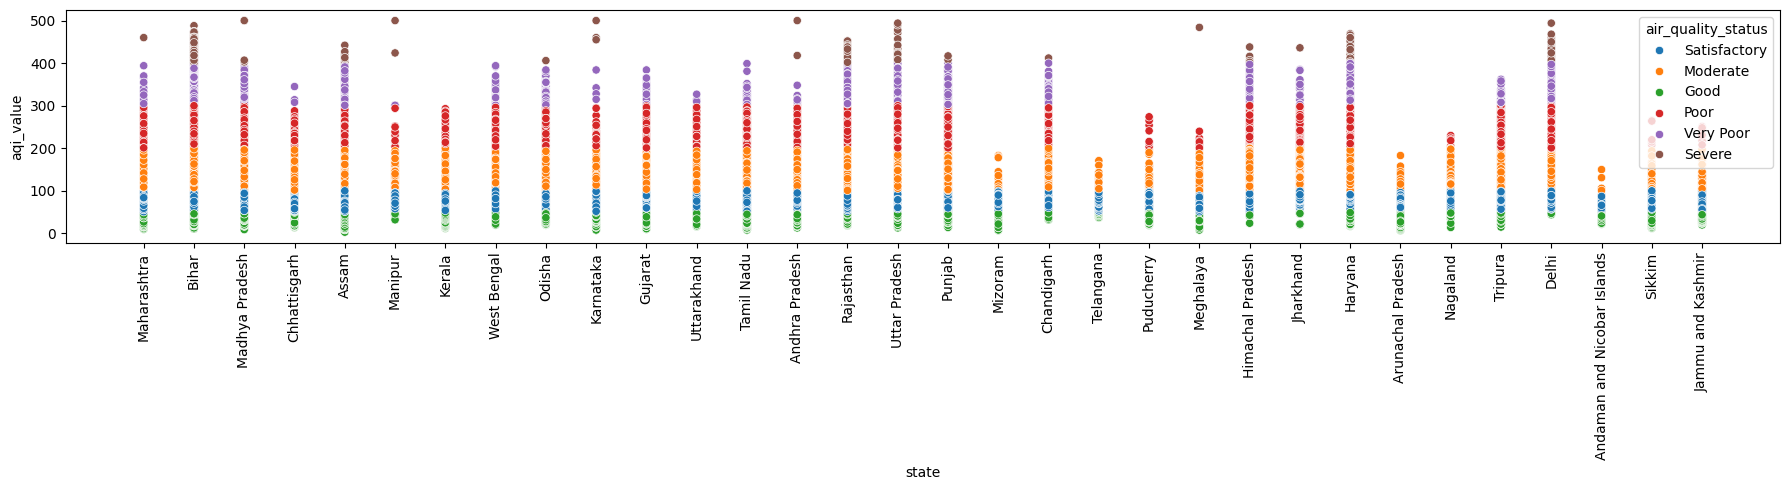

In [12]:
plt.figure(figsize=(18,5))

sns.scatterplot(data=df, x='state', y='aqi_value', hue='air_quality_status')
# Rotate x-axis labels by 90 degrees
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [13]:
# printng the areas that come under odisha


# as we can see there are total 11099 rows for odisha, but are only 16 areas of odisha which are mentioned here
print(df[df['state'] == 'Odisha']['area'].unique())

df[df['state'] == 'Odisha']

['Nayagarh' 'Bhubaneswar' 'Balasore' 'Angul' 'Keonjhar' 'Talcher'
 'Byasanagar' 'Rourkela' 'Suakati' 'Baripada' 'Cuttack' 'Brajrajnagar'
 'Barbil' 'Rairangpur' 'Tensa' 'Bileipada']


,date,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,pollutant 1,pollutant 2,pollutant 3
8,30-04-2025,Odisha,Nayagarh,1,58,Satisfactory,PM10,None,None
39,30-04-2025,Odisha,Bhubaneswar,2,94,Satisfactory,CO,None,None
44,30-04-2025,Odisha,Balasore,1,87,Satisfactory,O3,None,None
48,30-04-2025,Odisha,Angul,1,156,Moderate,O3,None,None
54,30-04-2025,Odisha,Keonjhar,1,71,Satisfactory,PM10,None,None
...,...,...,...,...,...,...,...,...,...
235195,04-04-2022,Odisha,Talcher,1,81,Satisfactory,CO,None,None
235590,02-04-2022,Odisha,Brajrajnagar,1,111,Moderate,PM10,None,None
235633,02-04-2022,Odisha,Talcher,1,86,Satisfactory,CO,None,None
235684,01-04-2022,Odisha,Talcher,1,37,Good,PM10,None,None


In [14]:
# checking the details for the Bhubaneswar location
print(df[df['state'] == 'Odisha'][df['area'] == 'Bhubaneswar'].shape)
df[df['state'] == 'Odisha'][df['area'] == 'Bhubaneswar']

(531, 9)


,date,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,pollutant 1,pollutant 2,pollutant 3
39,30-04-2025,Odisha,Bhubaneswar,2,94,Satisfactory,CO,None,None
402,29-04-2025,Odisha,Bhubaneswar,2,62,Satisfactory,CO,O3,None
575,28-04-2025,Odisha,Bhubaneswar,2,72,Satisfactory,CO,O3,None
837,27-04-2025,Odisha,Bhubaneswar,2,89,Satisfactory,CO,O3,None
1044,26-04-2025,Odisha,Bhubaneswar,2,52,Satisfactory,PM10,CO,None
...,...,...,...,...,...,...,...,...,...
128328,06-11-2023,Odisha,Bhubaneswar,2,108,Moderate,PM2.5,None,None
128670,05-11-2023,Odisha,Bhubaneswar,2,85,Satisfactory,CO,None,None
128803,04-11-2023,Odisha,Bhubaneswar,2,84,Satisfactory,CO,None,None
129113,03-11-2023,Odisha,Bhubaneswar,2,64,Satisfactory,CO,None,None


In [15]:
df[df['state'] == 'Odisha']['area'].value_counts()

area
Talcher         956
Rourkela        872
Baripada        807
Suakati         799
Bileipada       781
Brajrajnagar    762
Keonjhar        755
Nayagarh        751
Tensa           750
Rairangpur      748
Bhubaneswar     531
Balasore        525
Barbil          519
Byasanagar      518
Cuttack         516
Angul           509
Name: count, dtype: int64

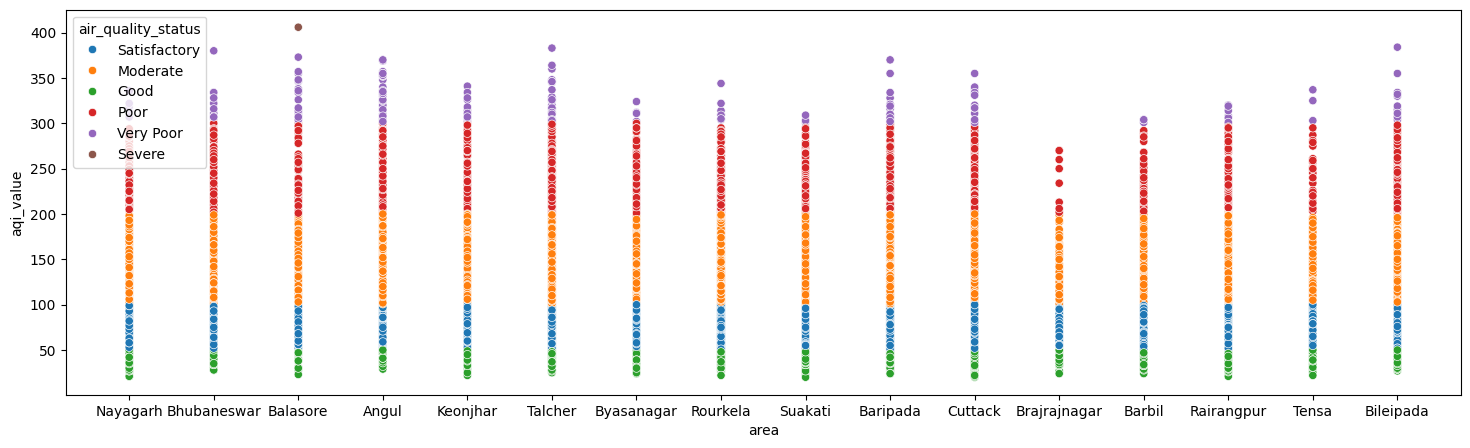

In [16]:
# plotting the aqi of cities of odisha

odisha = df[df['state'] == 'Odisha']


plt.figure(figsize=(18,5))
sns.scatterplot(data=odisha, x='area', y='aqi_value', hue=color)
plt.show()


In [17]:
more = df[df['state'] == 'Manipur']['area'].unique()


for i in df['state'].unique():
    if (df[df['state'] == i]['area'].nunique()) == 1:
        print(i)



Manipur
Mizoram
Chandigarh
Telangana
Puducherry
Meghalaya
Himachal Pradesh
Arunachal Pradesh
Nagaland
Tripura
Delhi
Andaman and Nicobar Islands
Sikkim
Jammu and Kashmir


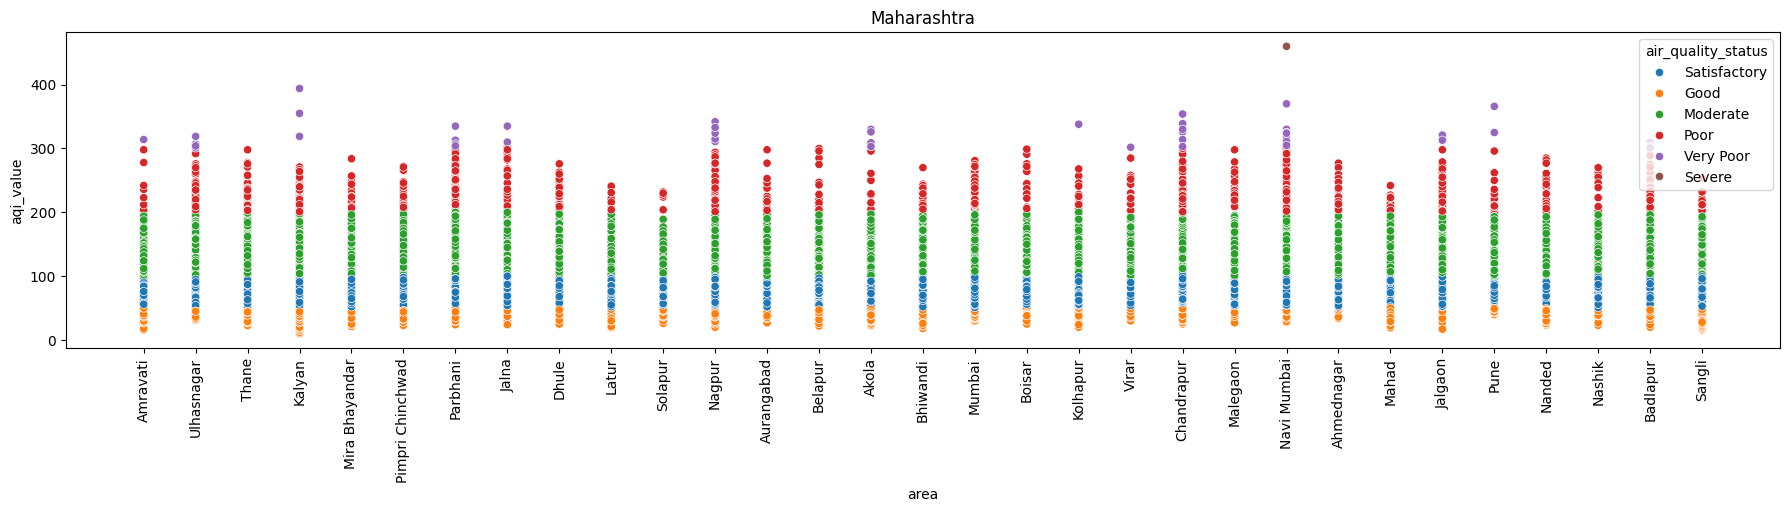

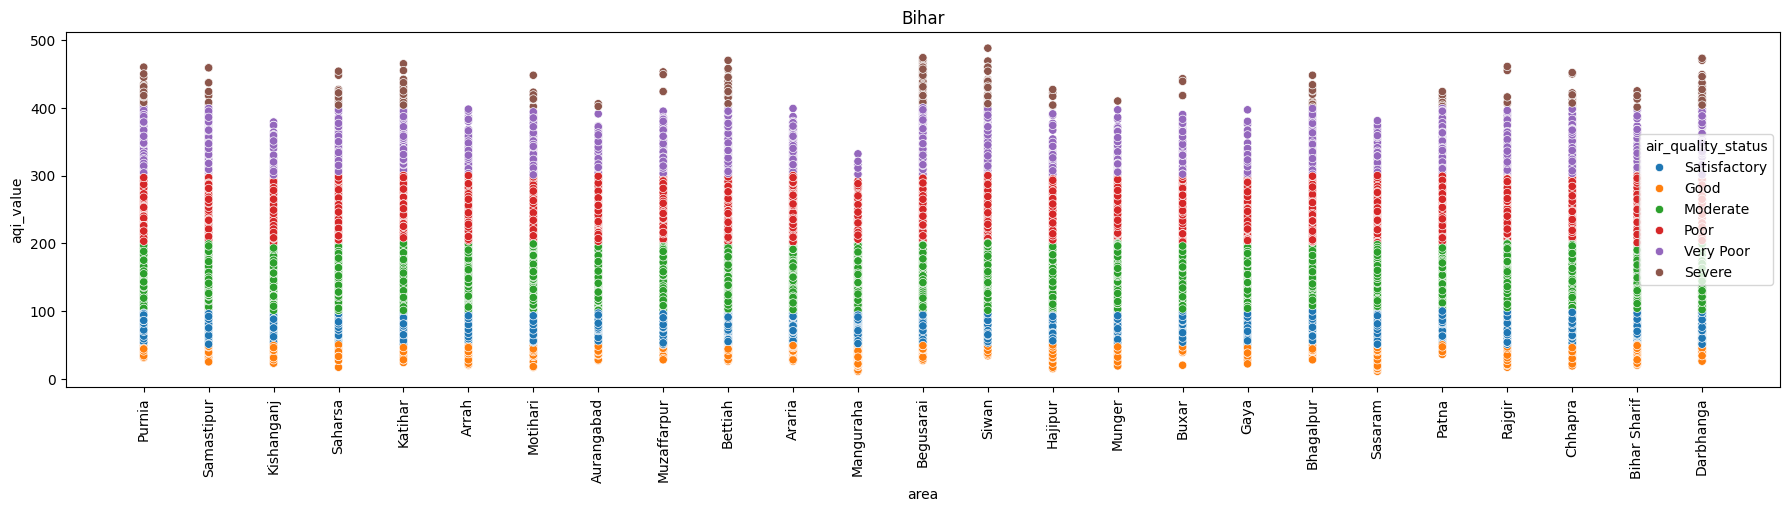

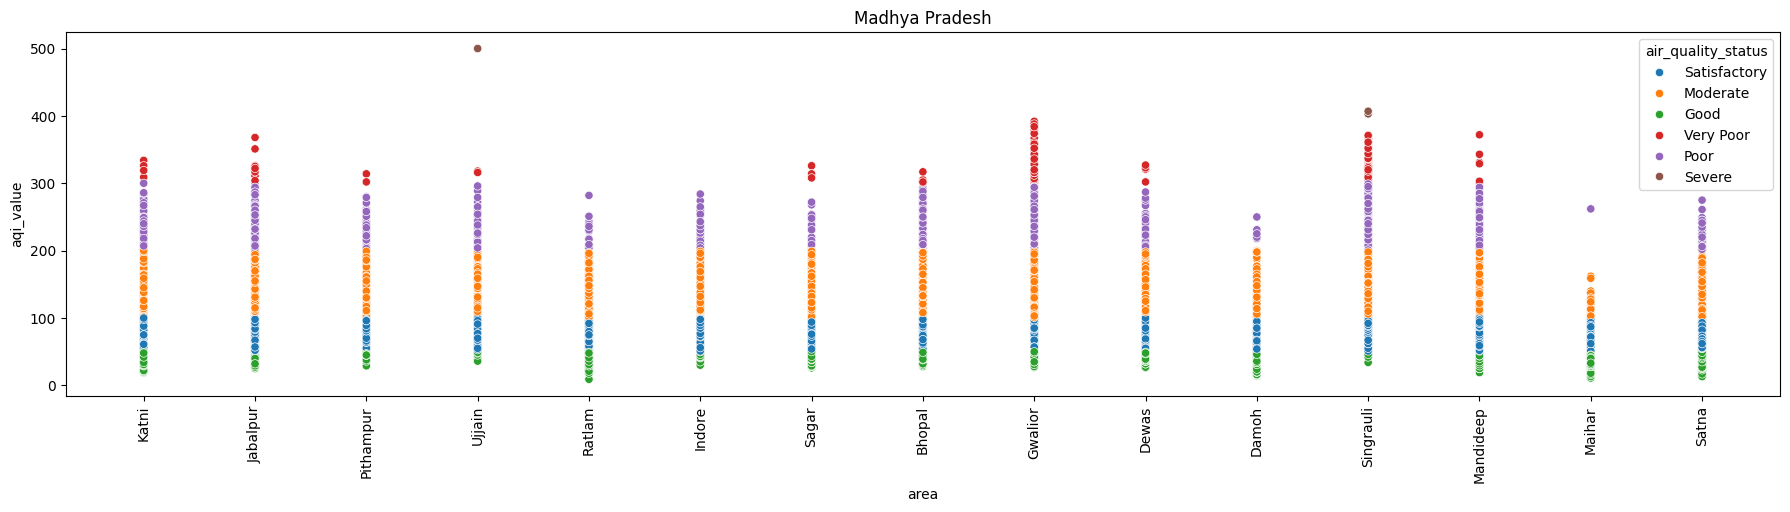

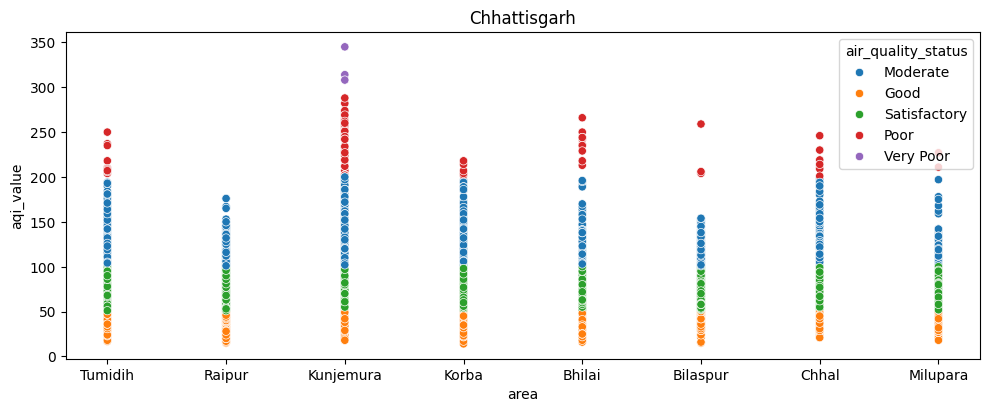

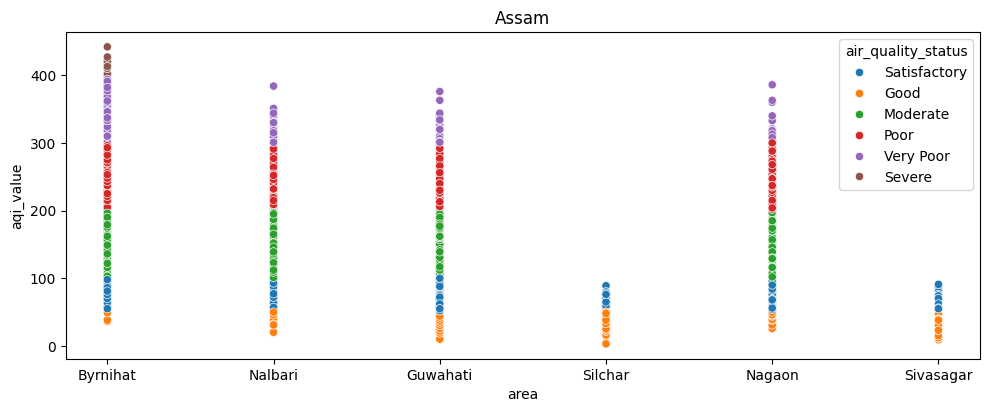

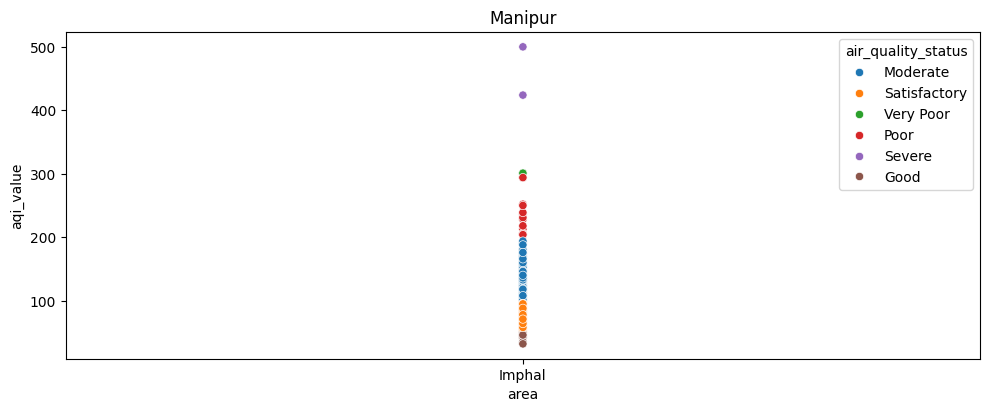

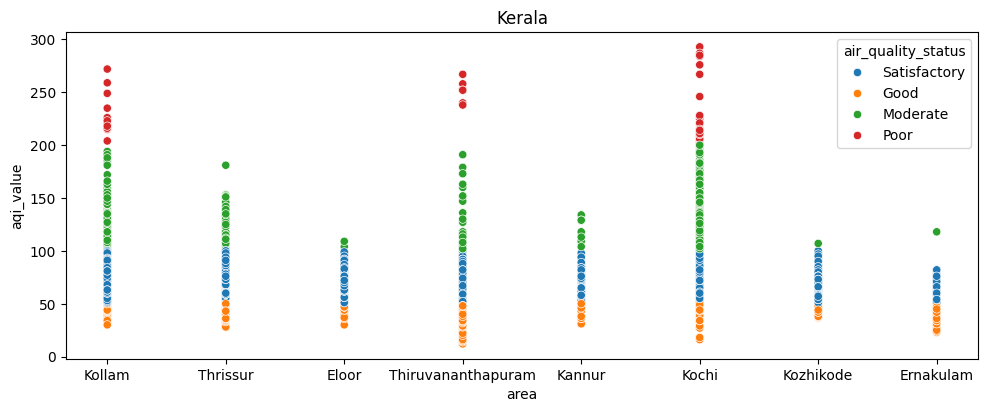

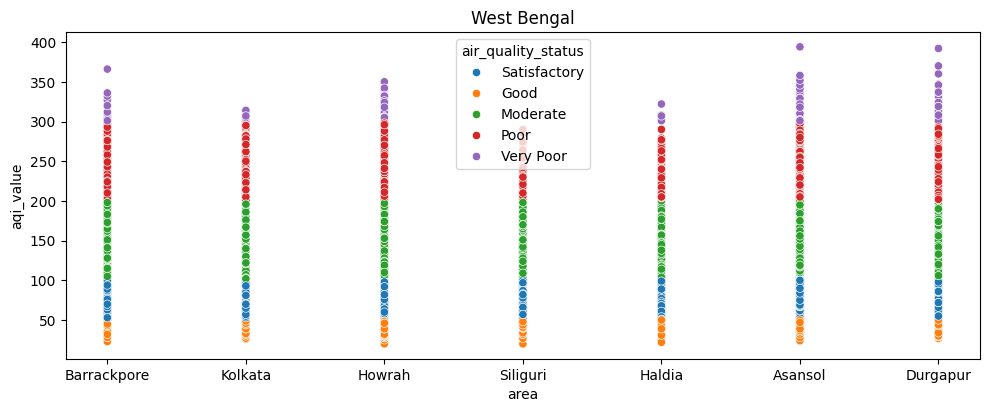

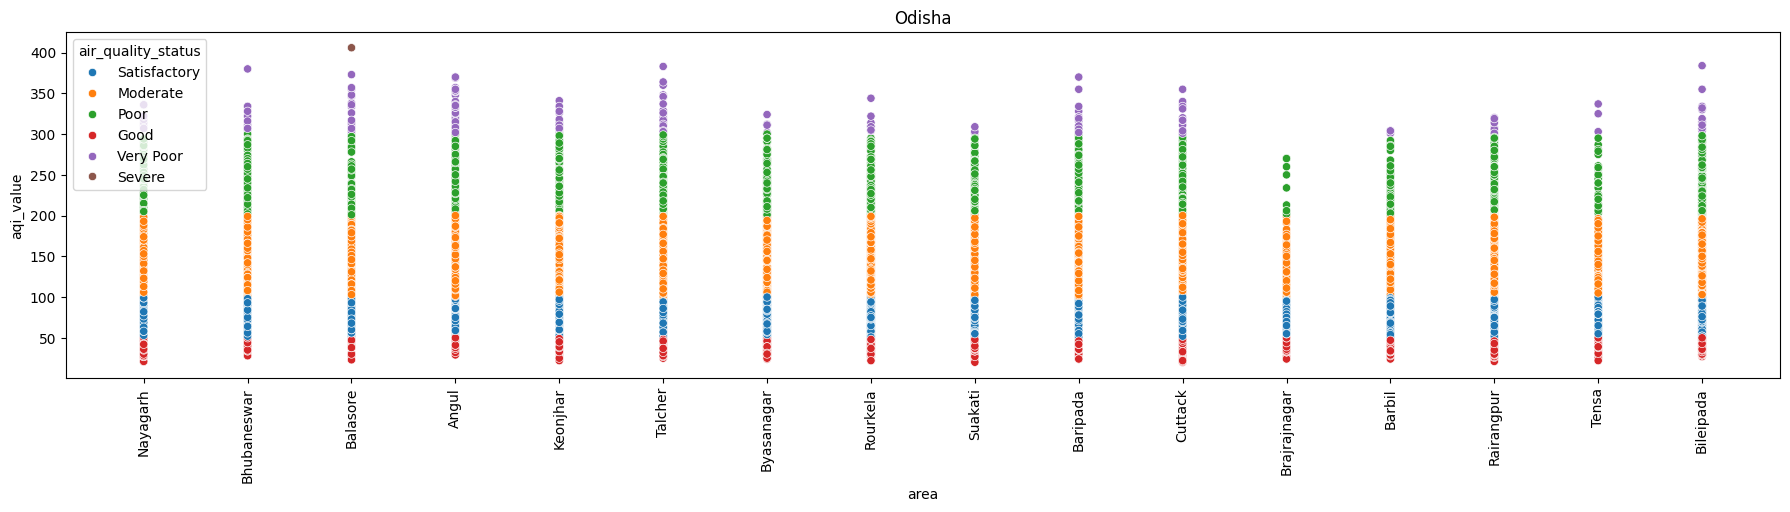

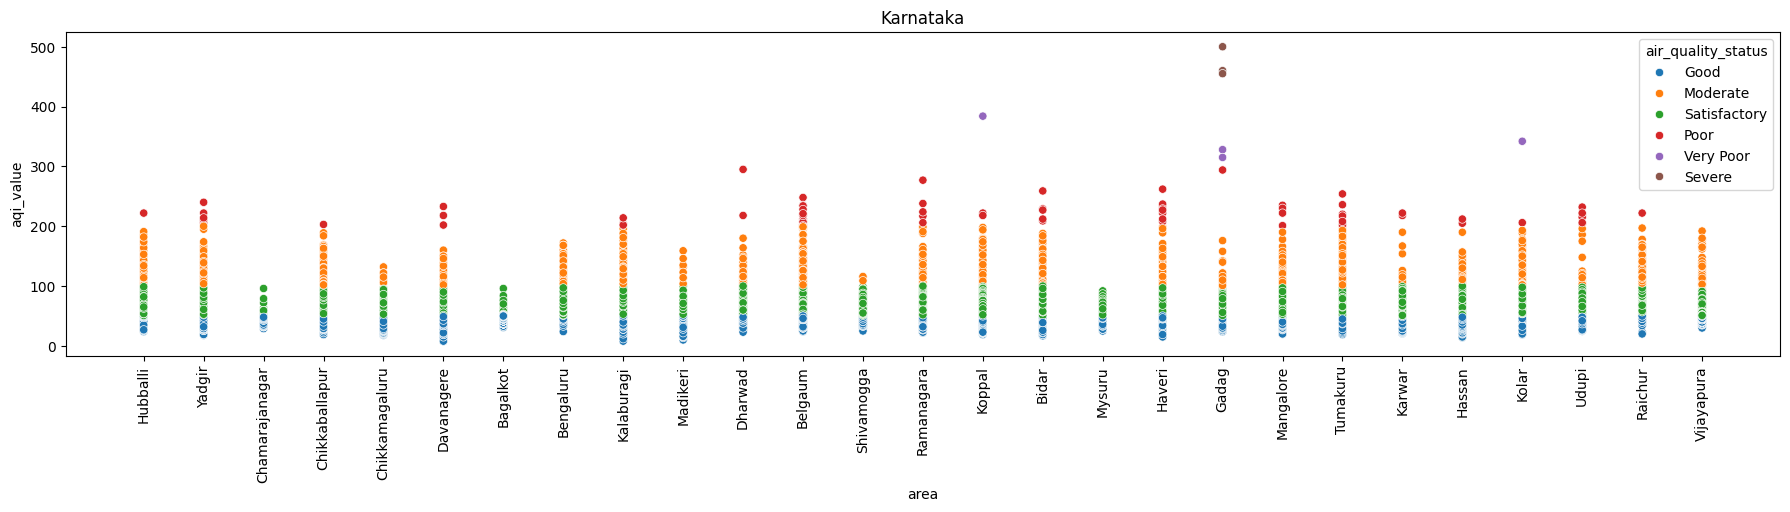

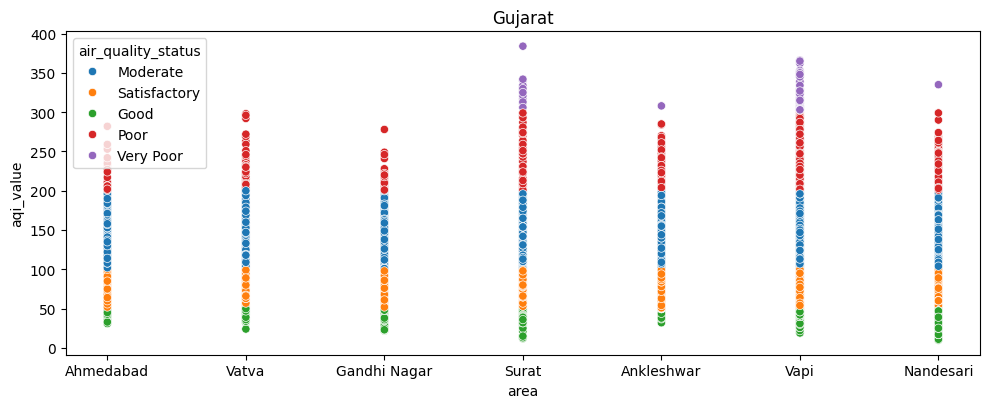

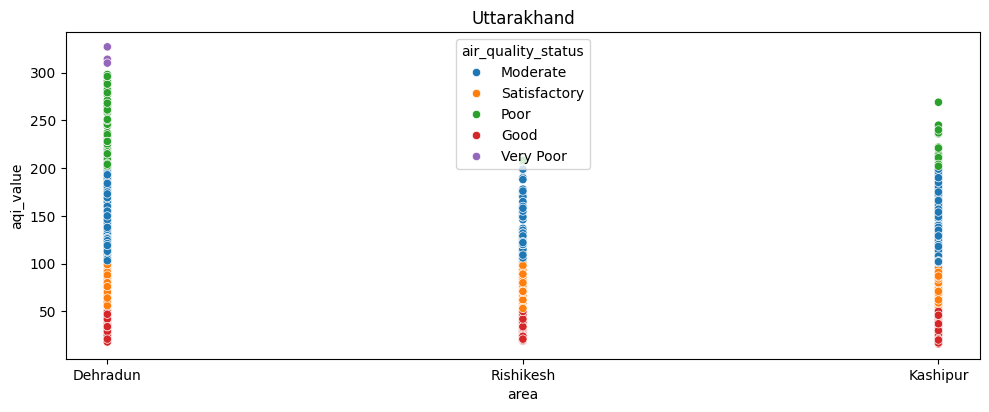

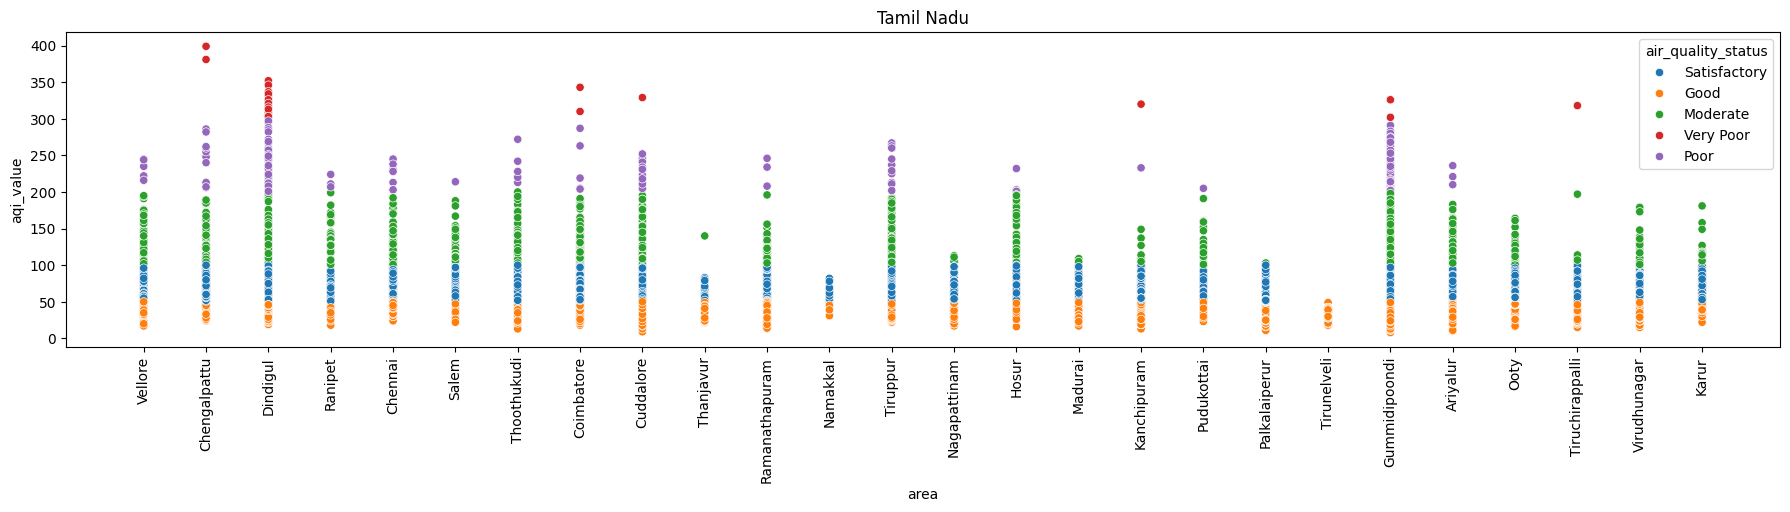

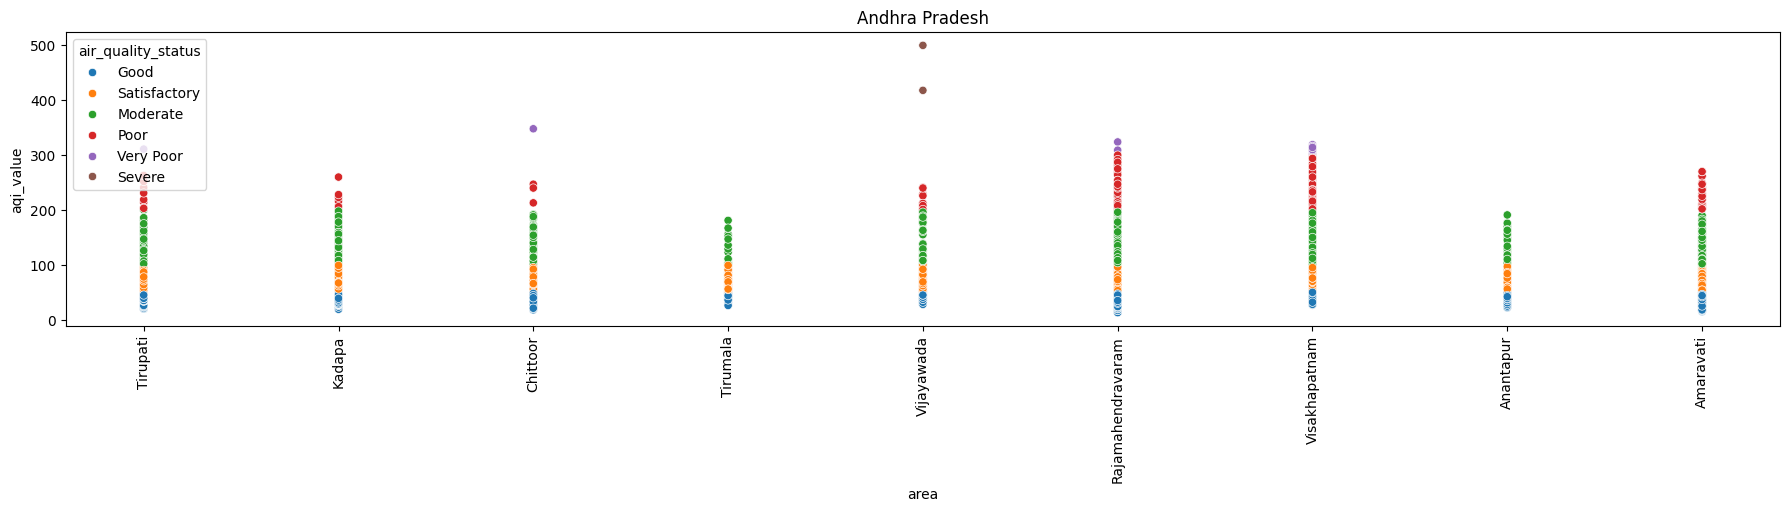

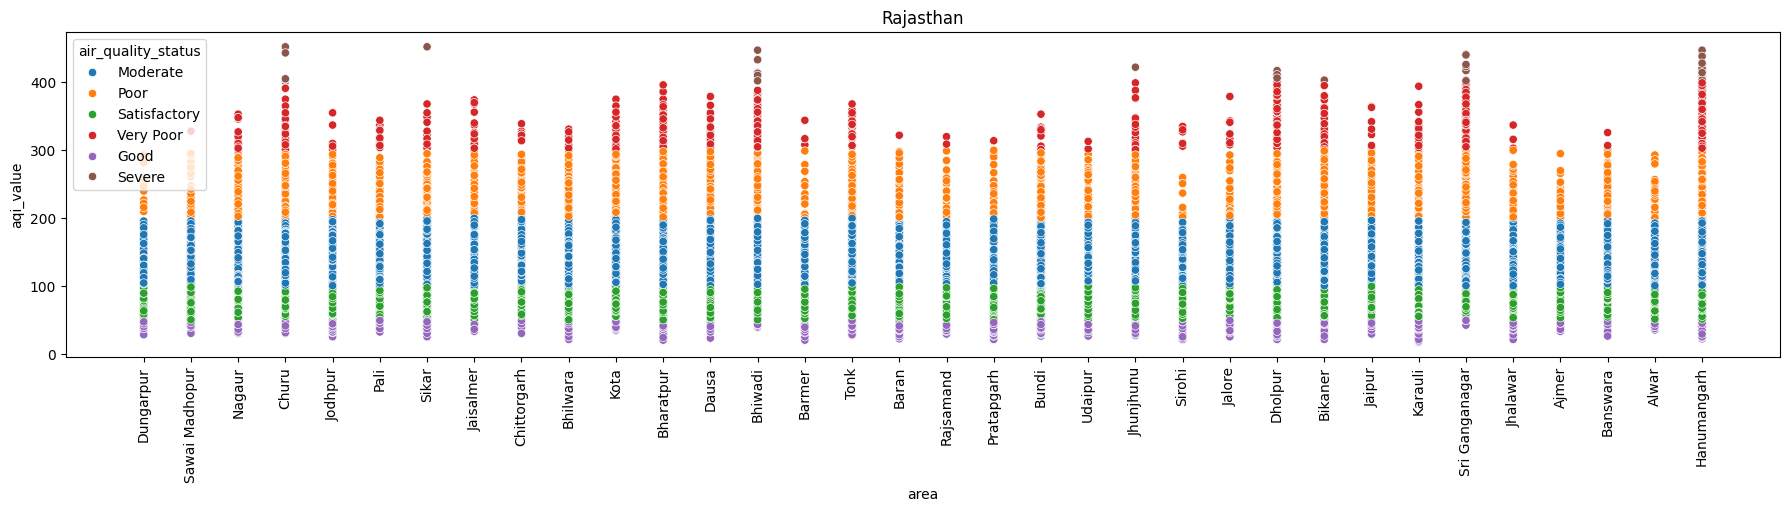

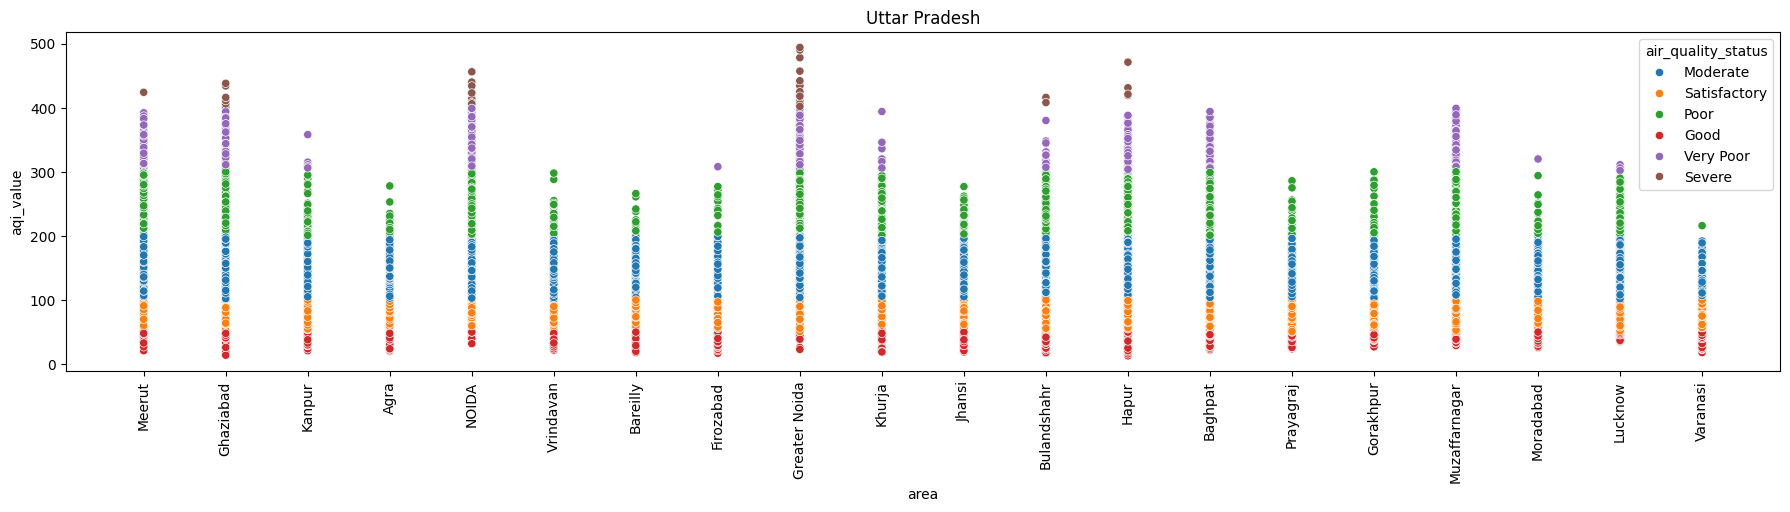

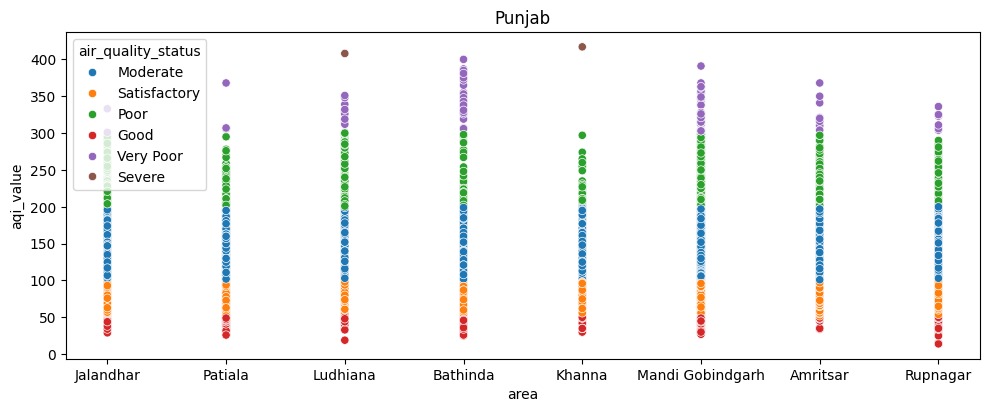

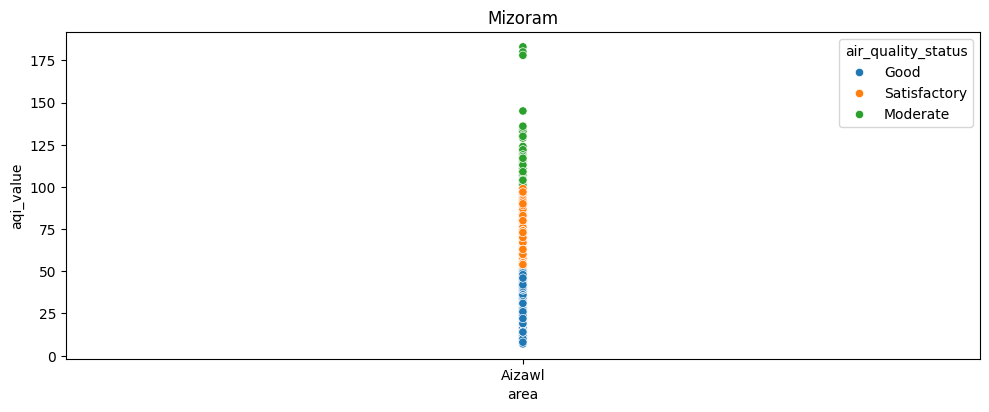

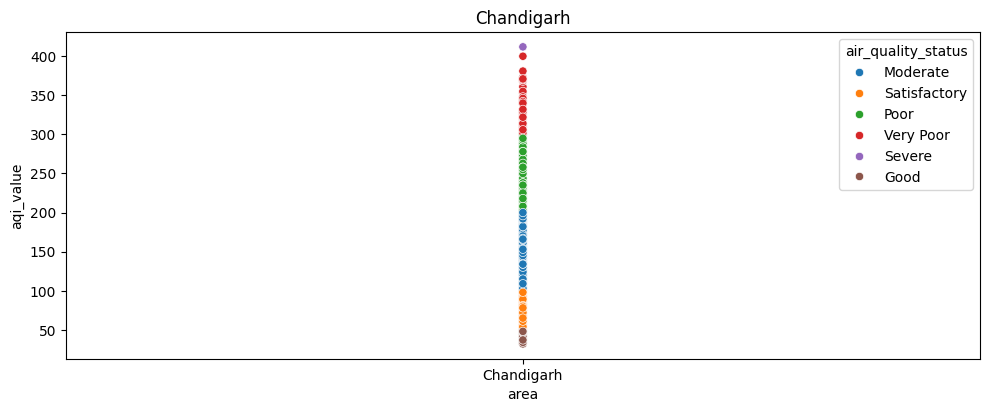

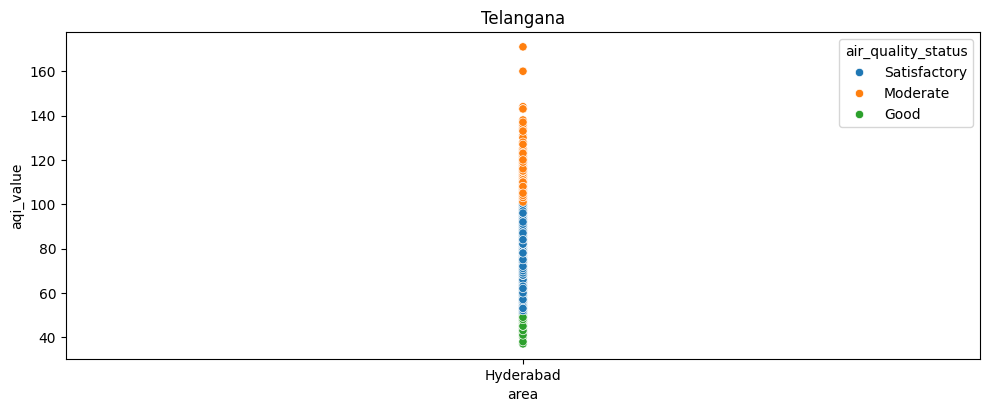

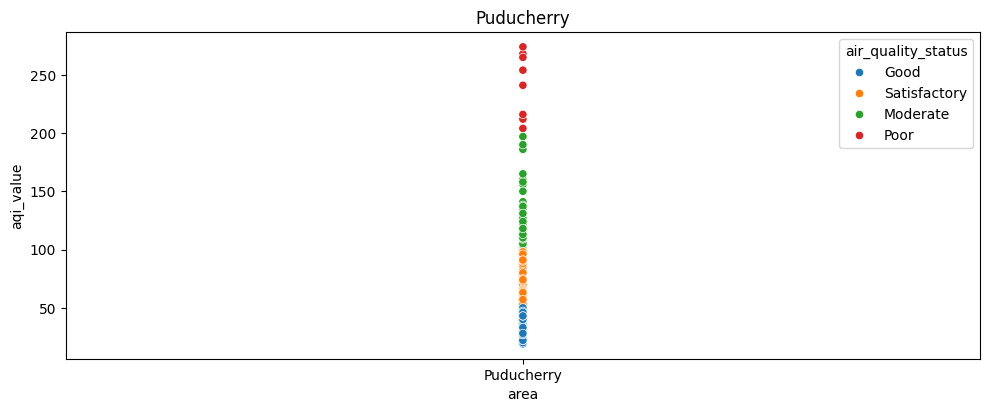

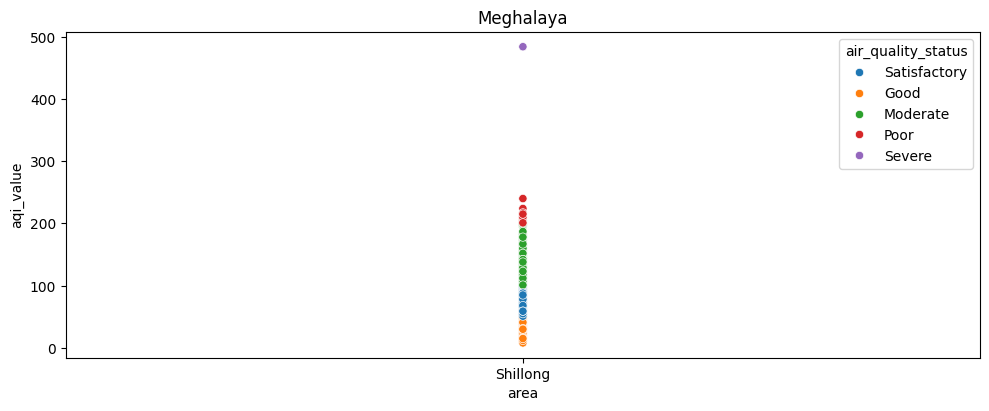

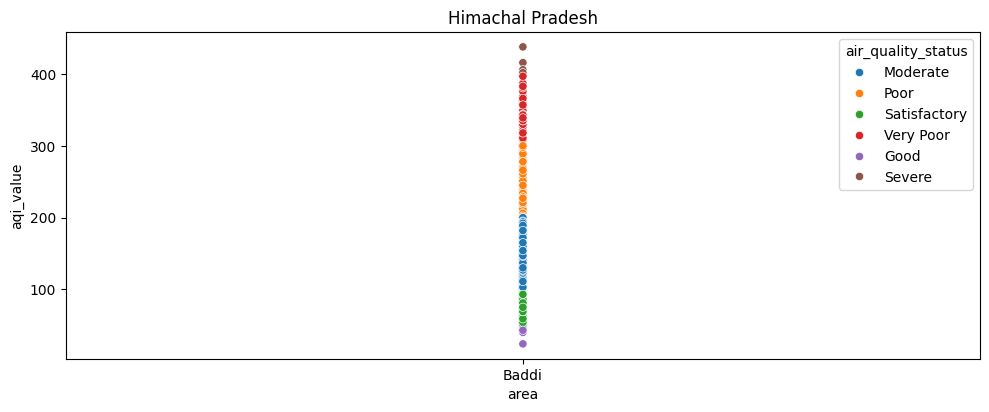

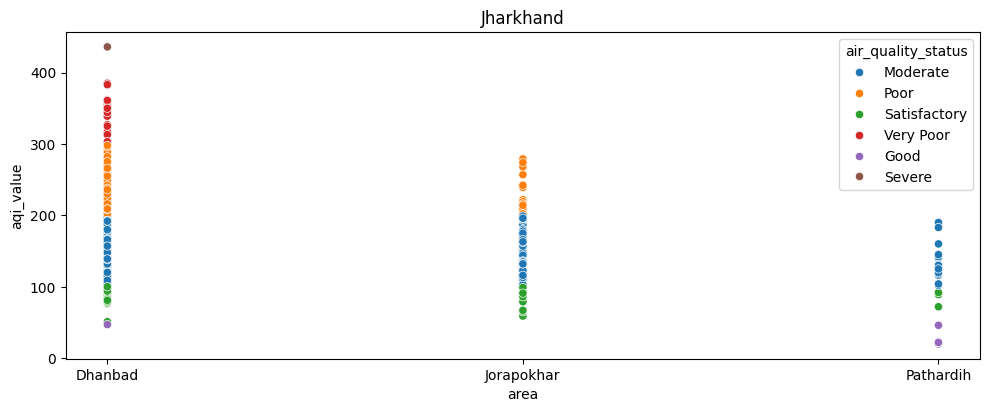

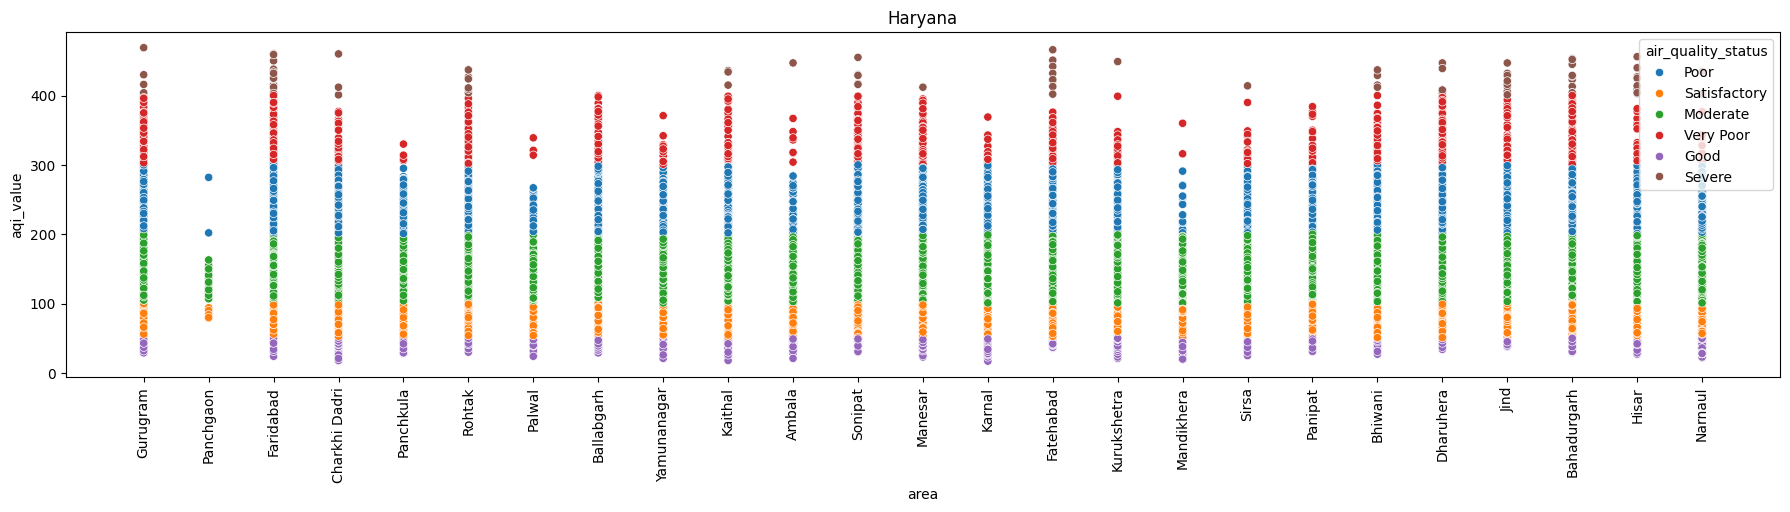

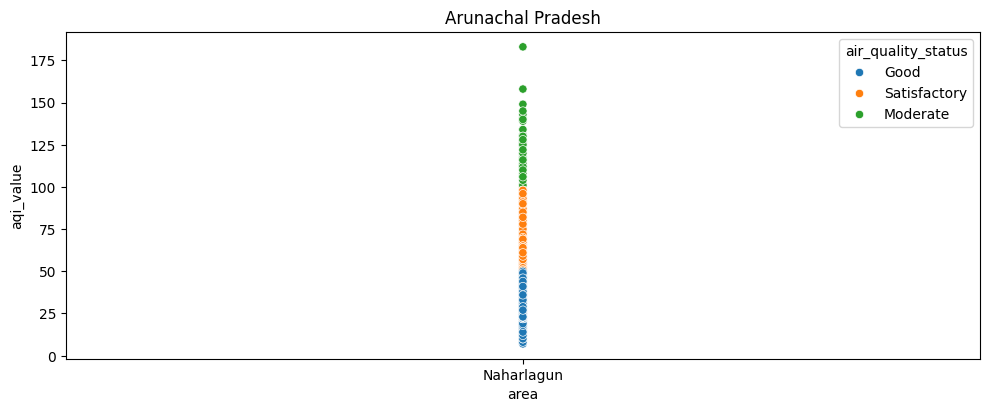

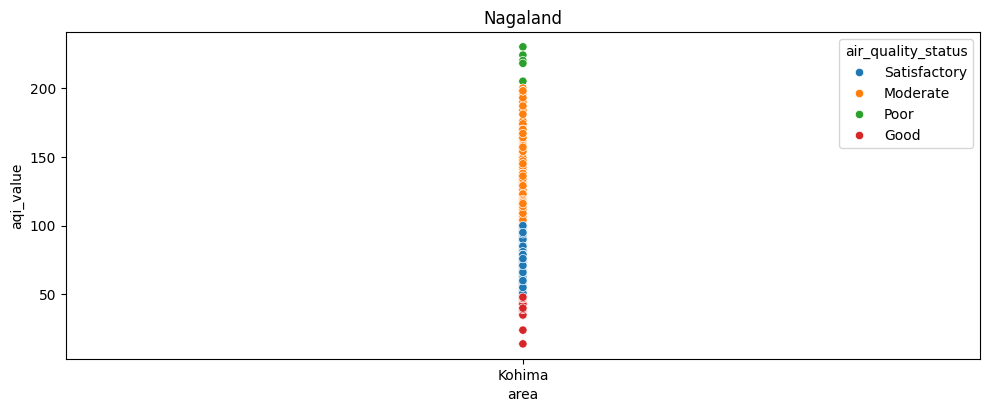

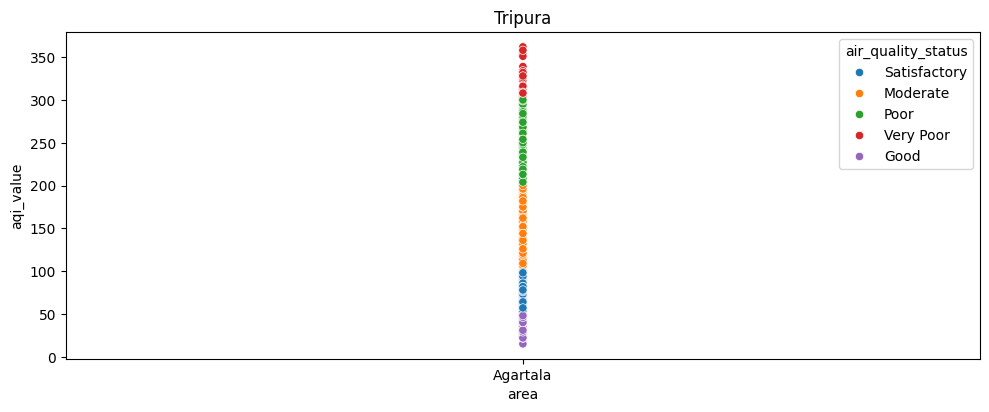

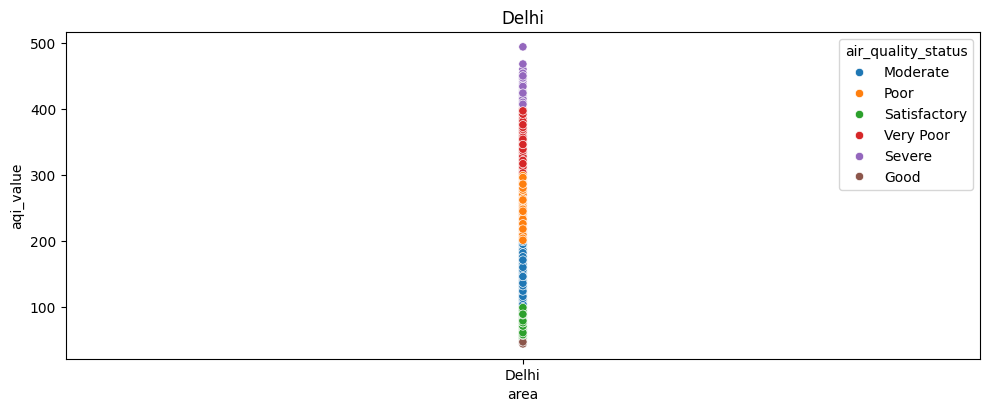

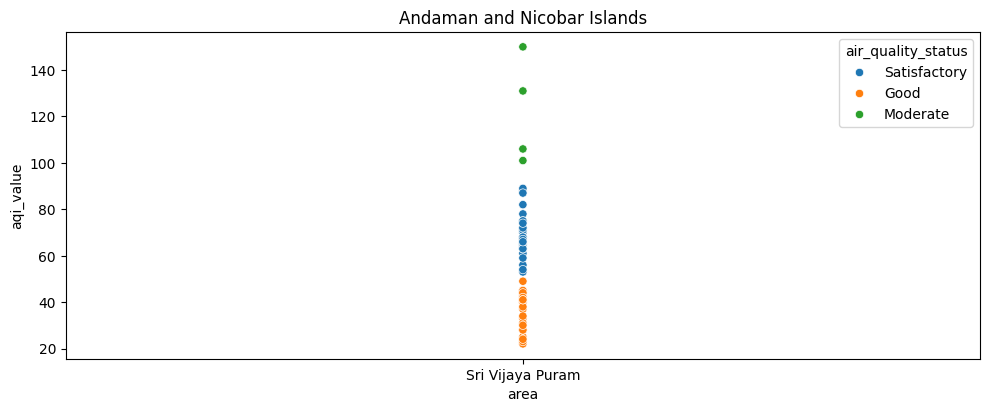

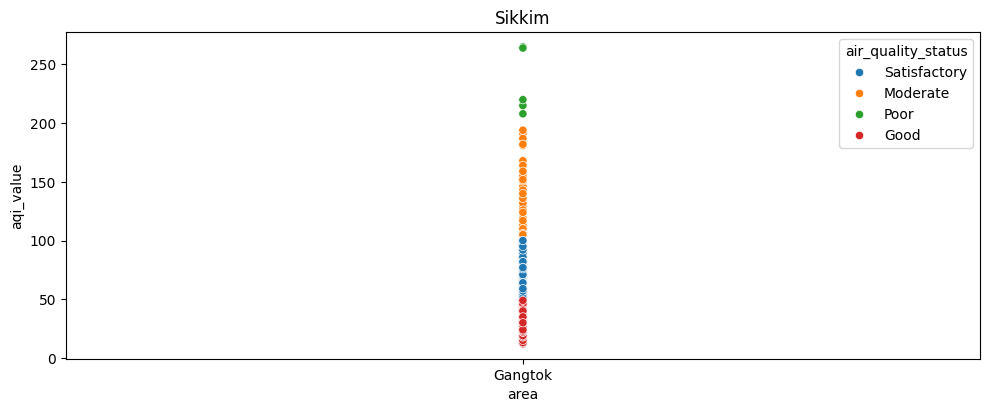

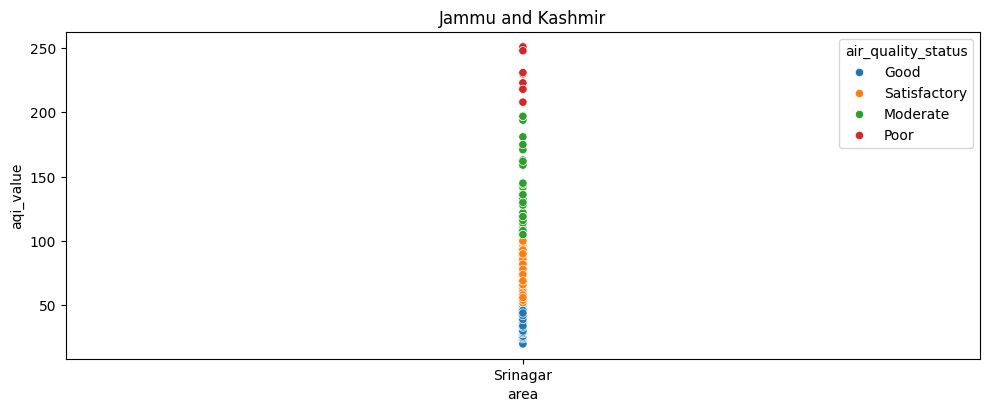

In [18]:
states = df['state'].unique()



for i in states:
    state_df = df[df['state'] == i]

    if (df[df['state'] == i]['area'].nunique()) <= 8:           # the states which has <= 3 area in the aqi, chaning their figure size
        plt.figure(figsize=(10, 4))
        sns.scatterplot(data=state_df, x='area', y='aqi_value', hue='air_quality_status')
        # plt.xticks(rotation=90)
        plt.tight_layout()
        plt.title(f"{i}")
        plt.show()
    else:
        plt.figure(figsize=(18, 5))
        sns.scatterplot(data=state_df, x='area', y='aqi_value', hue='air_quality_status')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.title(f"{i}")
        plt.show()





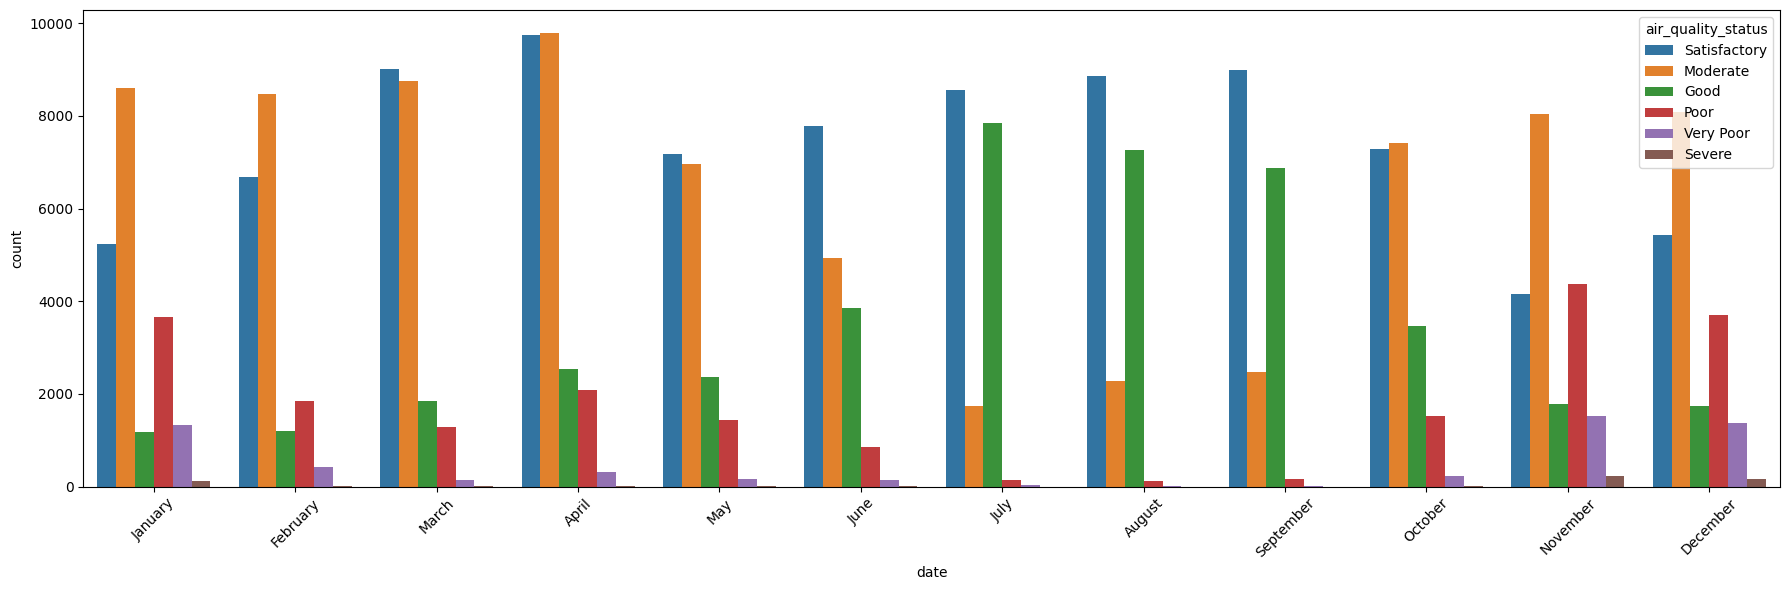

In [19]:
a = pd.to_datetime(df['date'], dayfirst=True) # dayfirst=True handles Indian date formats

b= a.dt.month_name()

# 2. Plotting (A Count Plot is better for Categories)
plt.figure(figsize=(18, 6))
# This shows the "Count" of each status per month
sns.countplot(data=df, x=b, hue='air_quality_status', 
              order=['January', 'February', 'March', 'April', 'May', 'June', 
                     'July', 'August', 'September', 'October', 'November', 'December'])

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## $$Feature Processing$$

---

In [20]:

print(df.info())
print()
print(df.describe())




df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   date                           235785 non-null  object
 1   state                          235785 non-null  object
 2   area                           235785 non-null  object
 3   number_of_monitoring_stations  235785 non-null  int64 
 4   aqi_value                      235785 non-null  int64 
 5   air_quality_status             235785 non-null  object
 6   pollutant 1                    235785 non-null  object
 7   pollutant 2                    29097 non-null   object
 8   pollutant 3                    3442 non-null    object
dtypes: int64(2), object(7)
memory usage: 16.2+ MB
None

       number_of_monitoring_stations      aqi_value
count                  235785.000000  235785.000000
mean                        1.870653     111.127294
std              

,date,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,pollutant 1,pollutant 2,pollutant 3
0,30-04-2025,Maharashtra,Amravati,2,78,Satisfactory,PM10,None,None
1,30-04-2025,Bihar,Purnia,1,56,Satisfactory,CO,None,None
2,30-04-2025,Madhya Pradesh,Katni,1,98,Satisfactory,O3,None,None
3,30-04-2025,Chhattisgarh,Tumidih,1,103,Moderate,PM10,None,None
4,30-04-2025,Assam,Byrnihat,1,61,Satisfactory,PM2.5,None,None
5,30-04-2025,Manipur,Imphal,1,106,Moderate,SO2,None,None
6,30-04-2025,Kerala,Kollam,1,73,Satisfactory,PM10,None,None
7,30-04-2025,West Bengal,Barrackpore,1,68,Satisfactory,PM10,None,None
8,30-04-2025,Odisha,Nayagarh,1,58,Satisfactory,PM10,None,None
9,30-04-2025,Assam,Nalbari,1,39,Good,PM10,None,None


In [21]:
# changing date time format
df['date'] = pd.to_datetime(df['date'])

df['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 235785 entries, 0 to 235784
Series name: date
Non-Null Count   Dtype         
--------------   -----         
235785 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.8 MB


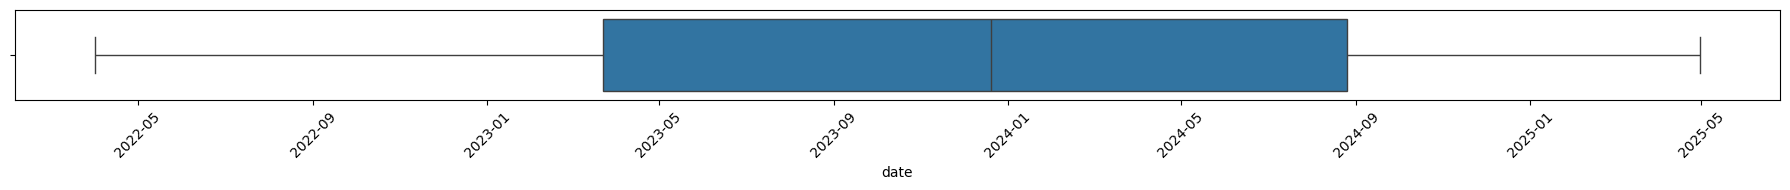

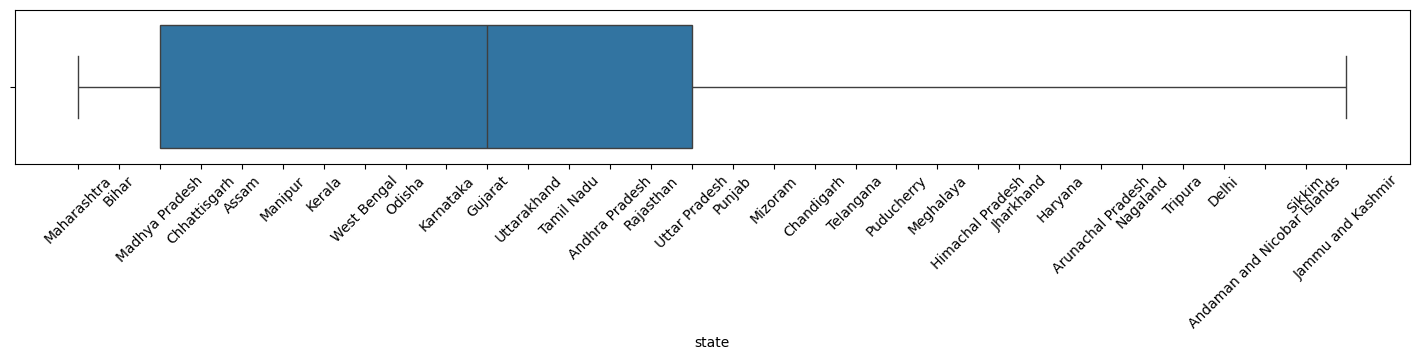

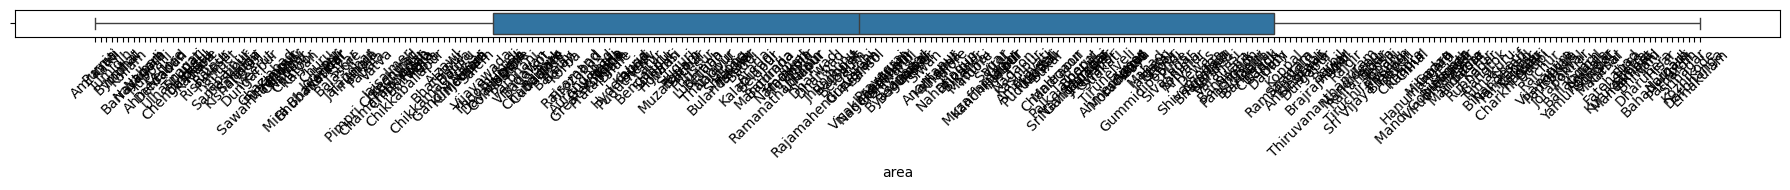

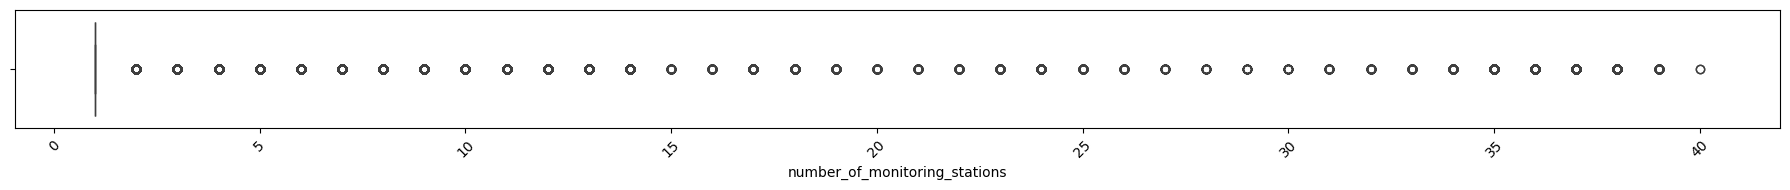

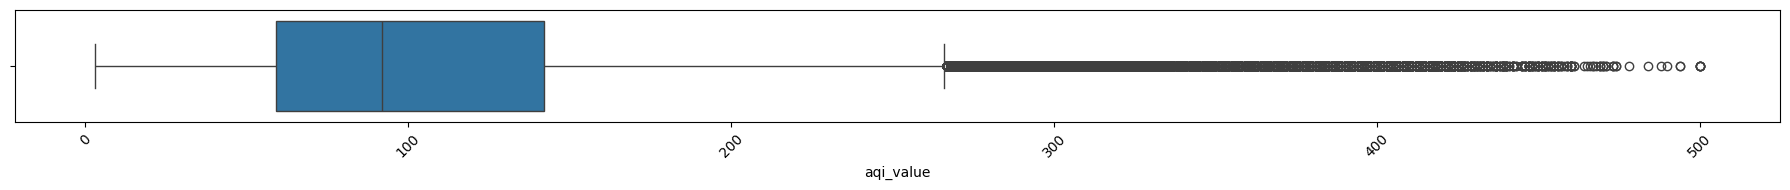

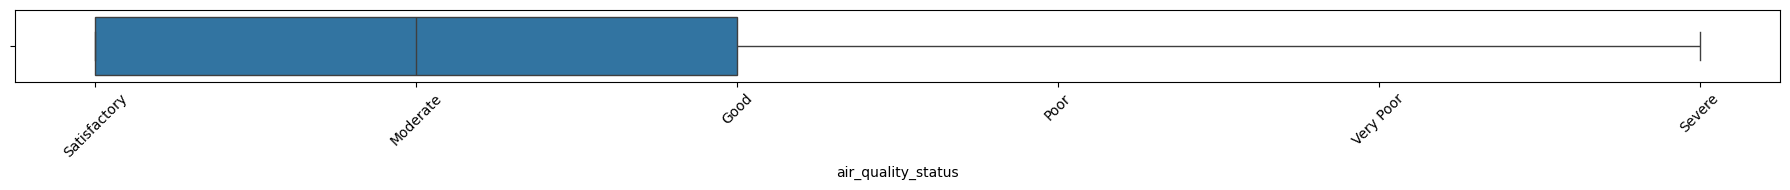

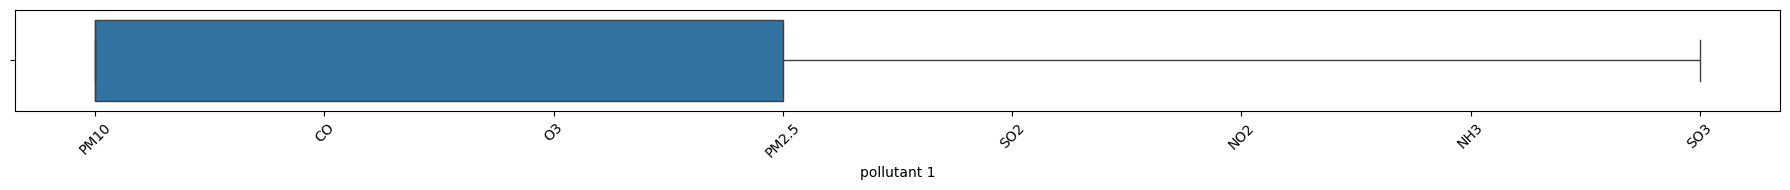

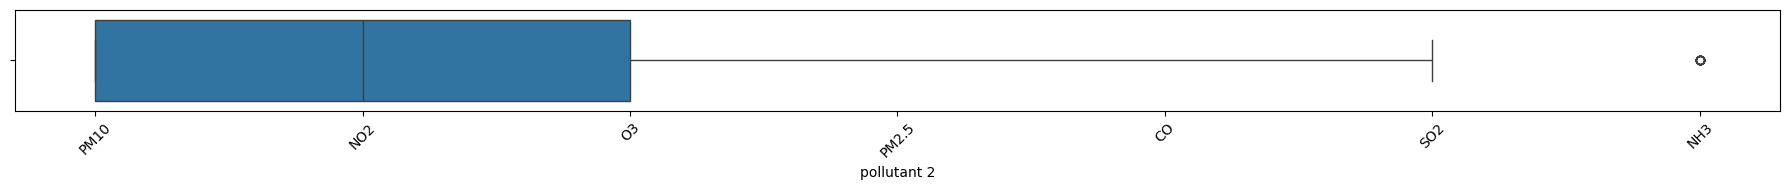

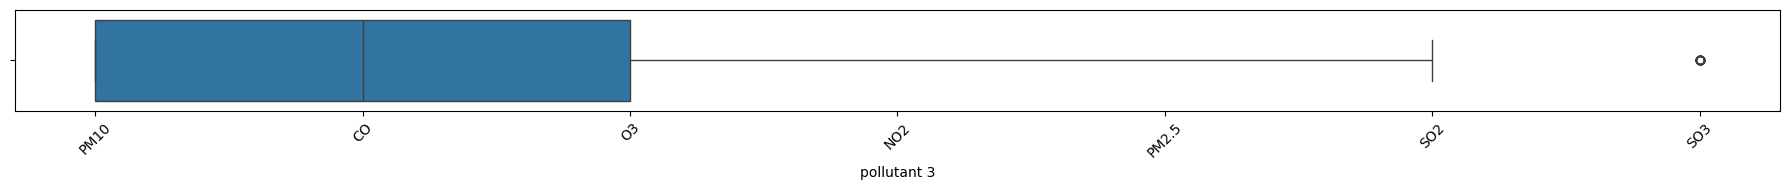

In [22]:
# checking for outliers

for i in df.columns:
    plt.figure(figsize=(18, 2))
    sns.boxplot(data=df, x=i)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



We will be applying IQR method only on 'aqi_value'

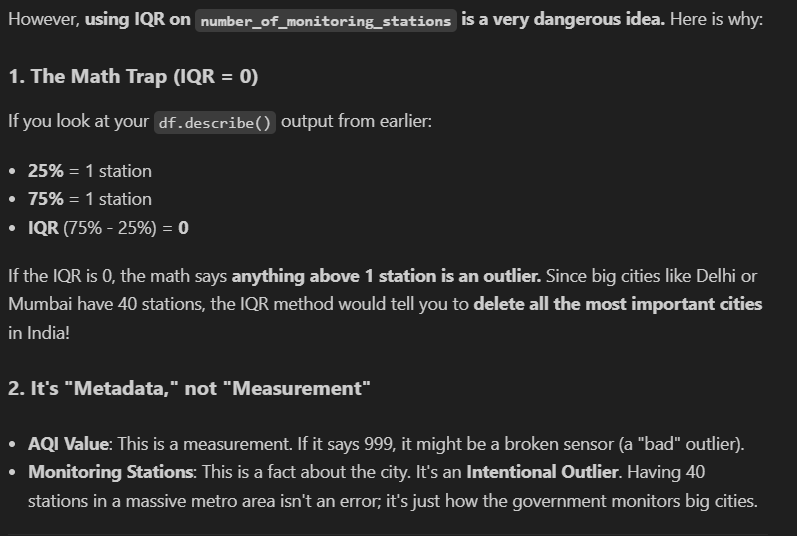


In [23]:
iqr_25 = df['aqi_value'].quantile(0.25)
iqr_75 = df['aqi_value'].quantile(0.75)

iqr_50 = iqr_75 - iqr_25

print(f"IQR 25 : {iqr_25}")
print(f"IQR 75 : {iqr_75}")
print(f"IQR 50 : {iqr_50}")
outliers = df[(df['aqi_value'] > iqr_75) | (df['aqi_value'] < iqr_25)]
non_outliers = df[(df['aqi_value'] < iqr_75) & (df['aqi_value'] > iqr_25)]

print(f"\nOUTLIERS : {outliers.shape}")
print(f"NON-OUTLIERS : {non_outliers.shape}")

IQR 25 : 59.0
IQR 75 : 142.0
IQR 50 : 83.0

OUTLIERS : (116719, 9)
NON-OUTLIERS : (116401, 9)


In [24]:
# # using stacking regressor to make prediction

# # here we will be using tree based models to that they can easily handle the outlier

# models = [
#     ('knn', KNeighborsRegressor(n_neighbors=10)),
#     ('lr', LinearRegression()),
#     ('rf', RandomForestRegressor(
#         n_estimators=100, 
#         random_state=42,
#         oob_score=True,
#         n_jobs=-1
#         )),
#     ('gbt', GradientBoostingRegressor(
#         n_estimators=100, 
#         learning_rate=0.1,
#         random_state=42, 
#         alpha=0.2,
#         n_iter_no_change=10,
#         validation_fraction=0.2,
#         tol=0.1
#         ))
# ]


# from sklearn.ensemble import StackingRegressor
# from sklearn.svm import SVR

# reg1 = StackingRegressor(
#     estimators=models,
#     final_estimator=Ridge(alpha=1),
#     cv=10,
#     n_jobs=-1
# )


# reg2 = StackingRegressor(
#     estimators=models,
#     final_estimator=Lasso(alpha=1),
#     cv=10,
#     n_jobs=-1
# )

# reg3 = StackingRegressor(
#     estimators=models,
#     final_estimator=SVR(kernel='rbf'),
#     cv=10,
#     n_jobs=-1
# )


# all_models = [
#     ('model 1', reg1),
#     ('model 2', reg2),
#     ('model 3', reg3)
# ]


# # making a meta model, that holds all the models in it
# meta = StackingRegressor(
#     estimators=all_models,
#     final_estimator=LinearRegression(),
#     cv=5,
#     n_jobs=-1
# )


In [40]:
from sklearn.preprocessing import MultiLabelBinarizer, TargetEncoder
import pandas as pd
import numpy as np

# Create a copy to avoid transforming original multiple times
data = df.copy()

# 1. Handle Status Mapping (Ordinal)
status_map = {
    'Good': 1, 'Satisfactory': 2, 'Moderate': 3, 
    'Poor': 4, 'Very Poor': 5, 'Severe': 6
}
if 'air_quality_status' in data.columns and data['air_quality_status'].dtype == 'object':
    data['air_quality_status'] = data['air_quality_status'].map(status_map)

# 2. Handle Pollutant List
# Check if we already have the split columns or need to create them
pollutant_cols = ['pollutant 1', 'pollutant 2', 'pollutant 3']
if 'prominent_pollutants' in data.columns:
    # If original string exists, we can use it directly
    data['pollutant_list'] = data['prominent_pollutants'].str.split(',')
elif all(col in data.columns for col in pollutant_cols):
    # If user already split them, combine them back to list (skipping None/NaN)
    data['pollutant_list'] = data[pollutant_cols].apply(
        lambda x: [i for i in x if i is not None and str(i) != 'nan' and str(i) != 'None'], axis=1
    )
else:
    print("Warning: Could not find pollutant source columns.")

# 3. MultiLabel Encoding
if 'pollutant_list' in data.columns:
    mlb = MultiLabelBinarizer()
    pollutant_array = mlb.fit_transform(data['pollutant_list'])
    pollutant_encoded = pd.DataFrame(
        pollutant_array, 
        columns=[f"is_{c}" for c in mlb.classes_], 
        index=data.index
    )
    data = pd.concat([data, pollutant_encoded], axis=1)

# 4. Target Encoding for State and Area
# This should only be done if they are still objects (not already encoded)
geo_cols = ['state', 'area']
if all(col in data.columns for col in geo_cols) and data['state'].dtype == 'object':
    te = TargetEncoder(target_type='continuous', random_state=42)
    data[['state', 'area']] = te.fit_transform(data[['state', 'area']], data['aqi_value'])

# 5. Final Cleanup: Drop all useless non-numeric columns
cols_to_drop = [
    'date', 'pollutant 1', 'pollutant 2', 'pollutant 3', 
    'prominent_pollutants', 'unit', 'note', 'pollutant_list'
]
df_final = data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors='ignore')

# Keep only numeric columns just in case
df_final = df_final.select_dtypes(include=[np.number])

print("Encoding Complete! Final Shape:", df_final.shape)
print("Final Columns:", df_final.columns.tolist())
df_final.head()

Encoding Complete! Final Shape: (235785, 13)
Final Columns: ['state', 'area', 'number_of_monitoring_stations', 'aqi_value', 'air_quality_status', 'is_CO', 'is_NH3', 'is_NO2', 'is_O3', 'is_PM10', 'is_PM2.5', 'is_SO2', 'is_SO3']


,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,is_CO,is_NH3,is_NO2,is_O3,is_PM10,is_PM2.5,is_SO2,is_SO3
0,103.636269,91.615903,2,78,2,0,0,0,0,1,0,0,0
1,157.292453,159.398674,1,56,2,1,0,0,0,0,0,0,0
2,108.862986,123.923771,1,98,2,0,0,0,1,0,0,0,0
3,79.044762,90.286063,1,103,3,0,0,0,0,1,0,0,0
4,114.434472,241.126238,1,61,2,0,0,0,0,0,1,0,0
